In [2]:
# train.py
import os
import json
from dataclasses import dataclass
from typing import List, Dict, Any
from functools import partial

import numpy as np
# from datasets import load_dataset, Dataset, concatenate_datasets
from torch.utils.data import Dataset 
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    Trainer,
AutoModelForCausalLM
)
from transformers.trainer_utils import get_last_checkpoint
from accelerate import Accelerator
import torch
from sklearn.model_selection import train_test_split
# from tasks import render_example
import torch.nn as nn
import pandas as pd

import torch

from dataclasses import dataclass
from typing import Dict, Any, Callable, Optional
import evaluate
import shutil
import glob
from datetime import datetime
from peft import LoraConfig, get_peft_model

In [4]:
c_res = pd.read_csv('../week23/modC_pred_scores')

In [6]:
c_res.columns

Index(['Unnamed: 0', 'survey_record_id', 'sentence_id', 'label',
       'consensus_label', 'type', 'topic', 'outlet', 'age', 'gender',
       'education', 'native_english_speaker', 'political_ideology',
       'followed_news_outlets', 'news_check_frequency', 'survey_completed',
       'label_binary', 'biased_count', 'total_count', 'poli_leaning_binned',
       'age_binned', 'education_binned', 'num_followed_outlets', 'emb_pca_1',
       'emb_pca_2', 'emb_pca_3', 'emb_pca_4', 'emb_pca_5', 'custom_idx',
       'out_emb1', 'out_emb2', 'out_emb3', 'p_hat', 'H_obs', 'H_pred',
       'H_model', 'text', 'modC_bias_pred', 'modC_ambi_pred'],
      dtype='object')

In [ ]:
'age', 
'gender', 
'education', 
'native_english_speaker', 
'political_ideology',
'followed_news_outlets'
'news_check_frequency', 
'survey_completed',
'label_binary',
        

'age_binned'
'gender', 
'education_binned'
'native_english_speaker',
'poli_leaning_binned',
'news_check_frequency',
'num_followed_outlets', 
'survey_completed',

In [21]:
# c_res['survey_completed'].value_counts()
# c_res['biased_count'].head()
c_res.group_by(

c_res[c_res['label_binary'] != c_res['label']].head()

,Unnamed: 0,survey_record_id,sentence_id,label,consensus_label,type,topic,outlet,age,gender,...,out_emb1,out_emb2,out_emb3,p_hat,H_obs,H_pred,H_model,text,modC_bias_pred,modC_ambi_pred
0,0,0045473f40ec42a2bd2ca0ee35df0b75,06e9e57e549d4dd48d8ac649ff81fd2e,Non-biased,NaN,right,gender,breitbart,29,Male,...,2.730163,-1.678505,-0.985302,0.326,0.439497,0.539638,-0.100141,The transgender effort to suppress any recogni...,1,0.025928
1,1,0045473f40ec42a2bd2ca0ee35df0b75,07f2137fd3ae4dd2b5c990b93e5c2a62,Non-biased,Biased,left,gun-control,alternet,29,Male,...,2.730163,-1.678505,-0.985302,0.272,0.439497,0.533147,-0.093650,Radical Virginia Citizens Defense League has o...,1,0.059802
2,2,0045473f40ec42a2bd2ca0ee35df0b75,10a5e68a84ab4c1a83d861b87c57def9,Non-biased,Biased,left,white-nationalism,msnbc,29,Male,...,2.730163,-1.678505,-0.985302,0.238,0.945660,0.855339,0.090321,Miller is the architect of President Donald Tr...,1,0.125324
3,3,0045473f40ec42a2bd2ca0ee35df0b75,17e77a14ecaa478fa81cf80e10f92e50,Non-biased,NaN,right,coronavirus,breitbart,29,Male,...,2.730163,-1.678505,-0.985302,0.704,0.845351,0.657247,0.188104,"The House Democrats 1,400-page coronavirus re...",1,0.173938
4,4,0045473f40ec42a2bd2ca0ee35df0b75,251232bf6ddf4bcbac7fb40a8aec1964,Non-biased,NaN,right,white-nationalism,federalist,29,Male,...,2.730163,-1.678505,-0.985302,0.818,0.684038,0.478035,0.206003,A specter is haunting the West; our elites see...,1,0.065084


In [9]:
c_res[c_res['consensus_label'] == 'No agreement']['modC_ambi_pred'].describe()

count    965.000000
mean       0.198972
std        0.049234
min        0.062660
25%        0.164200
50%        0.203495
75%        0.236426
max        0.319737
Name: modC_ambi_pred, dtype: float64

In [10]:
c_res[c_res['consensus_label'] != 'No agreement']['modC_ambi_pred'].describe()

count    16810.000000
mean         0.128204
std          0.083146
min          0.000467
25%          0.047897
50%          0.129452
75%          0.198850
max          0.333069
Name: modC_ambi_pred, dtype: float64

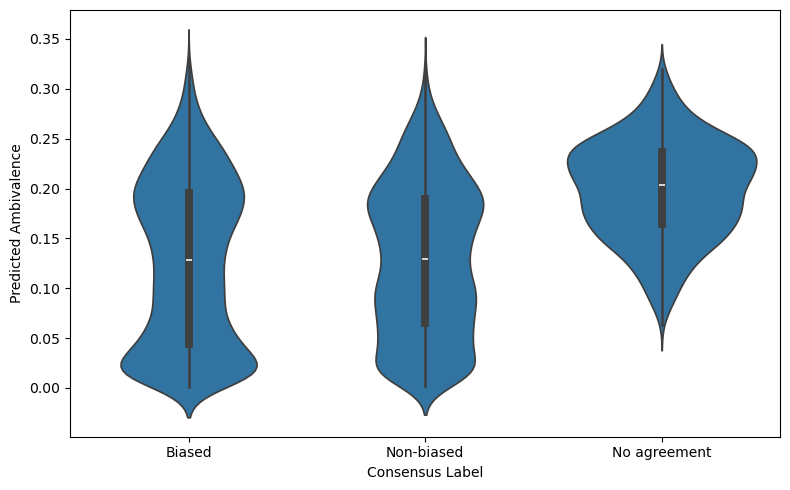

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=c_res, x='consensus_label', y='modC_ambi_pred', ax=ax)
ax.set_xlabel('Consensus Label')
ax.set_ylabel('Predicted Ambivalence')
plt.tight_layout()
plt.show()

In [12]:
c_res['poli_leaning_binned'].unique()

array(['Very Right', 'Very Left', 'Left', 'Center', 'Right'], dtype=object)

In [11]:
import statsmodels.formula.api as smf

# run for each demographic variable
for var in ['poli_leaning_binned', 'age_binned', 'education_binned', 
            'news_check_frequency', 'native_english_speaker']:
    model = smf.mixedlm(f"label_binary ~ C({var})", 
                         data=c_res, 
                         groups=c_res['sentence_id'])
    result = model.fit()
    print(var)
    print(result.summary())

poli_leaning_binned
                     Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        label_binary
No. Observations:        17775          Method:                    REML        
No. Groups:              1700           Scale:                     0.1902      
Min. group size:         9              Log-Likelihood:            -11603.8544 
Max. group size:         12             Converged:                 Yes         
Mean group size:         10.5                                                  
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.620    0.011 54.057 0.000  0.598  0.643
C(poli_leaning_binned)[T.Left]       -0.015    0.013 -1.164 0.244 -0.041  0.010
C(poli_leaning_binned)[T.Right]      -0.0

In [10]:
import sys
!{sys.executable} -m pip install statsmodels
import statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/40/c6/9ae8e9b0721e9b6eb5f340c3a0ce8cd7cce4f66e03dd81f80d60f111987f/statsmodels-0.14.6-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 73.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 13.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [5]:
import numpy as np

demo_vars = ['poli_leaning_binned', 'age_binned', 'education_binned', 
             'news_check_frequency', 'native_english_speaker']

results = {}
for var in demo_vars:
    # for each sentence, for each group value, get variance of labels
    within_var = (c_res
                  .groupby(['sentence_id', var])['label_binary']
                  .var()
                  .groupby('sentence_id')
                  .mean()
                  .mean())
    results[var] = within_var

for k, v in results.items():
    print(f"{k}: {v:.4f}")

poli_leaning_binned: 0.1907
age_binned: 0.1928
education_binned: 0.1872
news_check_frequency: 0.1897
native_english_speaker: 0.1917


In [19]:
from scipy import stats

demo_vars = ['poli_leaning_binned', 'age_binned', 'education_binned', 
             'news_check_frequency', 'native_english_speaker', 'gender','num_followed_outlets']

results = {}
for var in demo_vars:
    groups = [c_res[c_res[var] == g]['label_binary'].dropna() 
              for g in c_res[var].unique()]
    f, p = stats.f_oneway(*groups)
    results[var] = (f, p)

for k, (f, p) in results.items():
    print(f"{k}: F={f:.3f}, p={p:.4f}")

poli_leaning_binned: F=7.944, p=0.0000
age_binned: F=9.362, p=0.0000
education_binned: F=3.227, p=0.0397
news_check_frequency: F=9.887, p=0.0000
native_english_speaker: F=1.669, p=0.1884
gender: F=3.035, p=0.0481
num_followed_outlets: F=4.602, p=0.0000
